# Learning the committor
Reference papers: 
- _Kang, Trizio and Parrinello, [Nat Comput Sci](https://doi.org/10.1038/s43588-024-00645-0) (2024), [ArXiv](https://arxiv.org/abs/2401.05279)_
- _Trizio, Kang and Parrinello, [Nat Comput Sci](https://doi.org/10.1038/s43588-025-00799-5) (2025), [ArXiv](https://arxiv.org/abs/2410.17029)_

For a more practical example, see also the more advanced tutorial on training the committor for alanine dipeptide in the examples notebooks.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/luigibonati/mlcolvar/blob/main/docs/notebooks/tutorials/cvs_committor.ipynb)


## Setup

In [1]:
# Colab setup
import os

if os.getenv("COLAB_RELEASE_TAG"):
    import subprocess
    subprocess.run('wget https://raw.githubusercontent.com/luigibonati/mlcolvar/main/colab_setup.sh', shell=True)
    cmd = subprocess.run('bash colab_setup.sh TUTORIAL', shell=True, stdout=subprocess.PIPE)
    print(cmd.stdout.decode('utf-8'))

# IMPORT PACKAGES
import torch
import lightning
import numpy as np
import matplotlib.pyplot as plt

# IMPORT HELPER FUNCTIONS
from mlcolvar.utils.plot import muller_brown_potential, plot_isolines_2D, plot_metrics

# Set seed for reproducibility
torch.manual_seed(42)
torch.set_default_dtype(torch.float64)

/home/tdevergne@iit.local/anaconda3/envs/kooplearn-reborn/lib/python3.9/site-packages/lightning_utilities/core/imports.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Initialize committor model and training variables

In [2]:
from mlcolvar.cvs.committor import Committor,initialize_committor_masses

# temperature
T = 1 
# Boltzmann factor in the RIGHT ENREGY UNITS!
kb = 1
beta = 1/(kb*T)
print(f'Beta: {beta} \n1/beta: {1/beta}')

atomic_masses = initialize_committor_masses(atom_types=[0], masses=[1])

lr_scheduler = torch.optim.lr_scheduler.ExponentialLR
options = {'optimizer' : {'lr': 1e-3, 'weight_decay': 1e-5}, 
           'lr_scheduler' : { 'scheduler' : lr_scheduler, 'gamma' : 0.99999 }}

model = Committor(model=[2, 32, 32, 1],
                    atomic_masses=atomic_masses,
                    alpha=1e-1,
                    delta_f=0,
                    n_dim=2,
                    options=options)

Beta: 1.0 
1/beta: 1.0


## Load data
**NOTE** Here, as we only showcase the workings of the code, we directly use data collected at the end of the iterative process for convenience.
In general, however, one is supposed to collect a progressively better dataset through some iterations of the method, an example is availbale in the [more advanced tutorial on Alanine Dipeptide](https://github.com/luigibonati/mlcolvar/blob/main/docs/notebooks/examples/ex_committor.ipynb) in the examples section of the tutorials.

In [3]:
from mlcolvar.data import DictModule
from mlcolvar.utils.io import create_dataset_from_files
from mlcolvar.cvs.committor.utils import compute_committor_weights

################################### SET THINGS HERE ###################################
filenames = ['https://raw.githubusercontent.com/EnricoTrizio/committor_2.0/refs/heads/main/muller/unbiased_sims/A/COLVAR',
             'https://raw.githubusercontent.com/EnricoTrizio/committor_2.0/refs/heads/main/muller/unbiased_sims/B/COLVAR',
             'https://raw.githubusercontent.com/EnricoTrizio/committor_2.0/refs/heads/main/muller/biased_sims/iter_0/A/COLVAR',
             'https://raw.githubusercontent.com/EnricoTrizio/committor_2.0/refs/heads/main/muller/biased_sims/iter_0/B/COLVAR',
             'https://raw.githubusercontent.com/EnricoTrizio/committor_2.0/refs/heads/main/muller/biased_sims/iter_1/A/COLVAR',
             'https://raw.githubusercontent.com/EnricoTrizio/committor_2.0/refs/heads/main/muller/biased_sims/iter_1/B/COLVAR'
            ]

load_args = [{'start' : 0, 'stop': 2000, 'stride': 1},
             {'start' : 0, 'stop': 2000, 'stride': 1},
             {'start' : 1000, 'stop': 10000, 'stride': 1},
             {'start' : 1000, 'stop': 10000, 'stride': 1},
             {'start' : 1000, 'stop': 10000, 'stride': 1},
             {'start' : 1000, 'stop': 10000, 'stride': 1},
            ]           

# #######################################################################################

dataset, dataframe = create_dataset_from_files(file_names=filenames,
                                               create_labels=True,
                                               filter_args={'regex': 'p.x|p.y'}, # to load many positions --> 'regex': 'p[1-9]\.[abc]|p[1-2][0-9]\.[abc]'
                                               return_dataframe=True,
                                               load_args=load_args,
                                               verbose=True)
# fill empty entries from unbiased simulations
dataframe = dataframe.fillna({'opes.bias': 0})
dataframe = dataframe.fillna({'bias': 0})
bias = torch.Tensor(dataframe['opes.bias'].values + dataframe['bias'].values)

dataset = compute_committor_weights(dataset, bias, [0, 1, 2, 3, 4, 5], beta)

# create datamodule with only training set
datamodule = DictModule(dataset, lengths=[1])

/home/tdevergne@iit.local/anaconda3/envs/kooplearn-reborn/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Class 0 dataframe shape:  (2000, 13)
Class 1 dataframe shape:  (2000, 13)
Class 2 dataframe shape:  (9000, 24)
Class 3 dataframe shape:  (9000, 24)
Class 4 dataframe shape:  (9000, 24)
Class 5 dataframe shape:  (9000, 24)

 - Loaded dataframe (40000, 27): ['time', 'p.x', 'p.y', 'p.z', 'ene', 'pot.bias', 'pot.ene_bias', 'lwall.bias', 'lwall.force2', 'uwall.bias', 'uwall.force2', 'walker', 'labels', 'mueller', 'potential.bias', 'potential.mueller_bias', 'z.node-0', 'z.bias-0', 'q', 'bias', '@8.bias', '@8.bias_bias', 'opes.bias', 'opes.rct', 'opes.zed', 'opes.neff', 'opes.nker']
 - Descriptors (40000, 2): ['p.x', 'p.y']


### Visualize training set

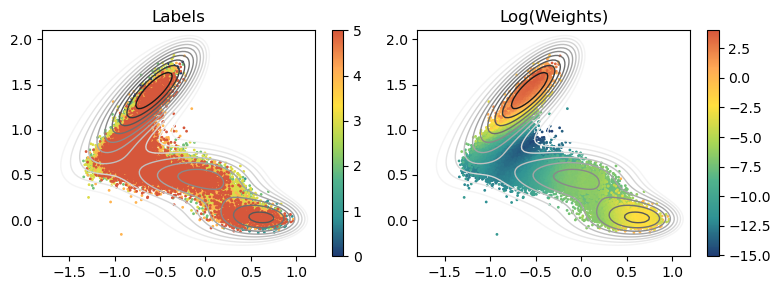

In [4]:
fig, axs = plt.subplots(1,2,figsize=(8,3))

# plot labels
ax = axs[0]
ax.set_title('Labels')

plot_isolines_2D(muller_brown_potential, levels=np.linspace(0,24, 12), ax=ax, max_value=24, colorbar=False, mode='contour', linewidths=1)
cp = ax.scatter(dataset['data'][:, 0], dataset['data'][:, 1], c=dataset['labels'], s=1, cmap='fessa')
plt.colorbar(cp, ax=ax)

# plot weights
ax = axs[1]
ax.set_title('Log(Weights)')
plot_isolines_2D(muller_brown_potential, levels=np.linspace(0,24, 12), ax=ax, max_value=24, colorbar=False, mode='contour', linewidths=1)
cp = ax.scatter(dataset['data'][:, 0], dataset['data'][:, 1], c=torch.log(dataset['weights']), s=1, cmap='fessa')
plt.colorbar(cp, ax=ax)

plt.tight_layout()
plt.show()

## Initialize trainer and fit model

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/tdevergne@iit.local/anaconda3/envs/kooplearn-reborn/lib/python3.9/site-packages/lightning/pytorch/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/home/tdevergne@iit.local/anaconda3/envs/kooplearn-reborn/lib/python3.9/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:653: Checkpoint directory /home/tdevergne@iit.local/Documents/generator_tutorials/notebooks/modelsave exists and is not empty.

  | Name    | Type           | Params | In sizes | Out sizes
------------------------------------------------------------------
0 | loss_fn | CommittorLoss  | 0      | ?        | ?        
1 | nn      | FeedForward    | 1.2 K  | [1, 2]   | [1, 1]   
2 | sigmoid | Custom_Sigmoid | 0      | [1, 1]   | [1, 1]   
------------------------------------------------------------------

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20000` reached.


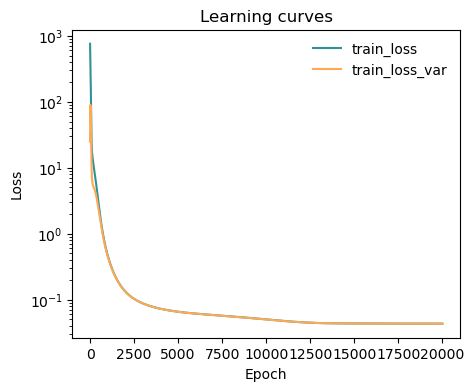

In [5]:
from mlcolvar.utils.trainer import MetricsCallback
from lightning.pytorch.callbacks import ModelCheckpoint

# define callbacks
metrics = MetricsCallback()
checkpoint_callback = ModelCheckpoint(dirpath="./modelsave/", save_top_k=10, monitor="train_loss_epoch", every_n_epochs=50)

# initialize trainer, for testing the number of epochs is low, change this to something like 4/5000 at least
trainer = lightning.Trainer(callbacks=[metrics, checkpoint_callback], max_epochs=20000, logger=False, enable_checkpointing=True,
            limit_val_batches=0, num_sanity_val_steps=0, accelerator='cpu'
        )

# fit model
trainer.fit(model, datamodule)

# plot metrics
ax = plot_metrics(metrics.metrics,
                  keys=['train_loss', 'train_loss_var'],
                  colors=['fessa1','fessa5'],
                  yscale='log')

## Visualize results

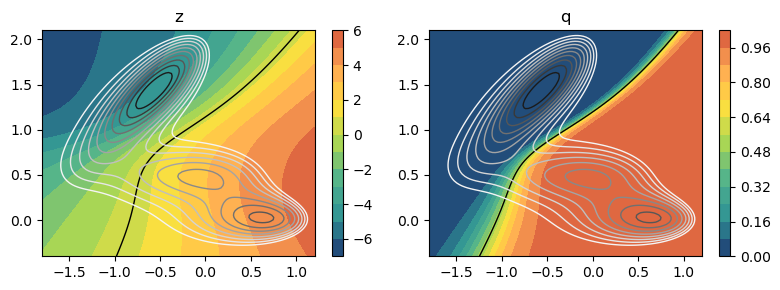

In [6]:
# save sigmoid activation of output layer to go from z to q
import copy
Sigmoid = copy.copy(model.sigmoid)

fig, axs = plt.subplots(1,2,figsize=(8,3))

# plot z --> sigmoid activation off
ax = axs[0]
ax.set_title('z')
model.sigmoid = None
plot_isolines_2D(model, ax=ax, colorbar=True)
plot_isolines_2D(model, ax=ax, colorbar=True, levels=[0.5], mode='contour', linewidths=1)
plot_isolines_2D(muller_brown_potential, levels=np.linspace(0,24, 12), ax=ax, max_value=24, colorbar=False, mode='contour', linewidths=1)

# plot q --> sigmoid activation on
ax = axs[1]
ax.set_title('q')
model.sigmoid = Sigmoid
plot_isolines_2D(model, ax=ax, colorbar=True)
plot_isolines_2D(model, ax=ax, colorbar=True, levels=[0.5], mode='contour', linewidths=1)
plot_isolines_2D(muller_brown_potential, levels=np.linspace(0,24, 12), ax=ax, max_value=24, colorbar=False, mode='contour', linewidths=1)
plt.tight_layout()
plt.show()

## Visualize Kolmogorov bias 

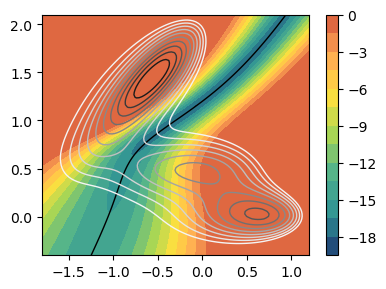

In [7]:
from mlcolvar.cvs.committor.utils import KolmogorovBias

model_bias = KolmogorovBias(input_model=model, beta=beta, epsilon=1e-6, lambd=1)

fig, ax = plt.subplots(1,1,figsize=(4,3))
plot_isolines_2D(model_bias, ax=ax, colorbar=True, allow_grad=True)
plot_isolines_2D(model, ax=ax, colorbar=True, levels=[0.5], mode='contour', linewidths=1)
plot_isolines_2D(muller_brown_potential, levels=np.linspace(0,24, 12), ax=ax, max_value=24, colorbar=False, mode='contour', linewidths=1)
plt.tight_layout()
plt.show()

In [8]:
model.nn

FeedForward(
  (nn): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [9]:
from mlcolvar.cvs import Generator
model_generator =  Generator(model=[2,32,32],eta=50.0,r=32,alpha=1.0,friction=torch.Tensor([1/10]),n_dim=2)

In [10]:
model_generator.nn = torch.nn.Sequential(*list(model.nn.nn)[:-1])

In [11]:
eigenfunctions,evals, evecs = model_generator.cpu().compute_eigenfunctions(dataset,eta=0.0005, batch_size=500,tikhonov_reg=1e-8,recompute=True)

In [12]:
evals

tensor([ 7.3330e-16, -1.4495e-04, -5.6115e-01, -4.9901e+00, -5.3691e+00,
        -7.2013e+00, -8.7105e+00, -1.0259e+01, -1.1918e+01, -1.3655e+01,
        -1.4530e+01, -1.9355e+01, -2.1396e+01, -2.1791e+01, -2.9204e+01,
        -3.0627e+01, -3.5290e+01, -3.9960e+01, -4.9980e+01, -5.2678e+01,
        -5.6692e+01, -5.9454e+01, -6.2327e+01, -6.3969e+01, -7.1770e+01,
        -7.8499e+01, -8.4713e+01, -9.2816e+01, -9.9083e+01, -1.1063e+02,
        -1.2023e+02, -1.5025e+02, -9.5195e+06])

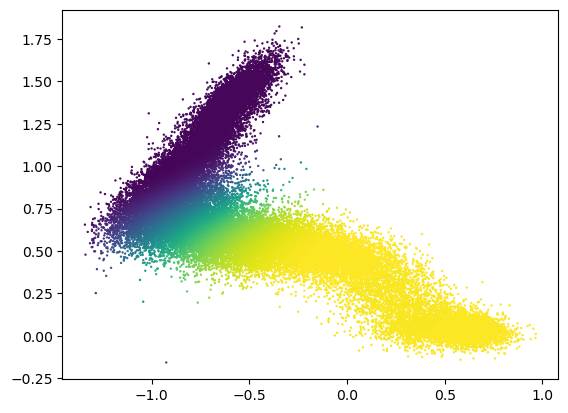

In [15]:
plt.scatter(dataset["data"][:,0].detach(),dataset["data"][:,1].detach(),c=-eigenfunctions[:,1].detach(),s=0.5)
#plot_isolines_2D(muller_brown_potential, levels=np.linspace(0,24, 12), max_value=24, colorbar=False, mode='contour', linewidths=1)
##plt.colorbar()


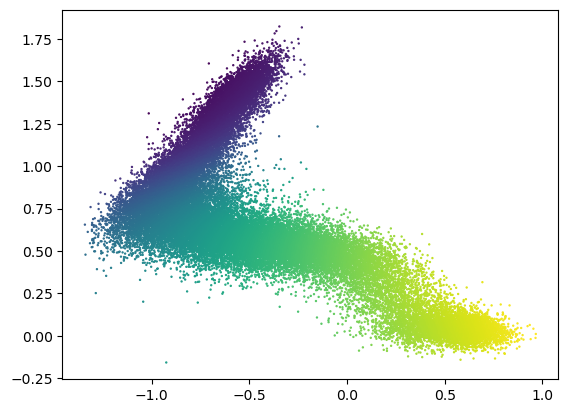

In [14]:
plt.scatter(dataset["data"][:,0].detach(),dataset["data"][:,1].detach(),c=model.nn(dataset["data"]).detach(),s=0.5)
